In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_exoplanets.csv")
print(df.shape)

(5757, 17)


In [42]:
def score_gaussian(value, ideal, tolerance):
    if pd.isna(value):
        return np.nan
    return np.exp(-((value - ideal) ** 2) / (2 * tolerance ** 2))

array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>]], dtype=object)

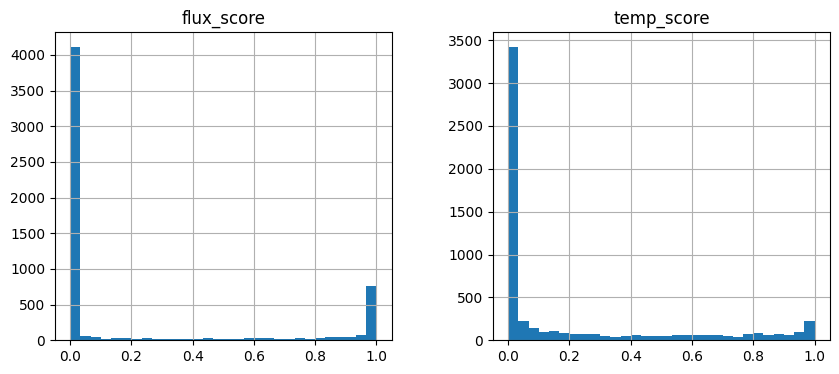

In [43]:
# Flux: widen tolerance significantly — real data spans orders of magnitude
df['flux_score'] = df['pl_insol'].apply(lambda x: score_gaussian(x, ideal=1.0, tolerance=5.0))

# Temperature: widen too — most planets are hundreds of K away from 255K
df['temp_score'] = df['pl_eqt'].apply(lambda x: score_gaussian(x, ideal=255, tolerance=150))

df[['flux_score','temp_score']].hist(figsize=(10,4), bins=30)

In [44]:
def score_asymmetric(value, ideal, tol_low, tol_high):
    if pd.isna(value):
        return np.nan
    tol = tol_low if value < ideal else tol_high
    return np.exp(-((value - ideal) ** 2) / (2 * tol ** 2))

# Radius: ideal = 1.0 Earth radii
df['radius_score'] = df['pl_rade'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.5, tol_high=0.6))

# Density proxy: ideal = 1.0 (Earth-like rocky density)
df['density_score'] = df['density_proxy'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.4, tol_high=0.8))

print(df[['pl_rade', 'radius_score', 'density_proxy', 'density_score']].describe())

           pl_rade  radius_score  density_proxy  density_score
count  5722.000000  5.722000e+03    5701.000000    5701.000000
mean      5.709506  2.263208e-01       2.530757       0.453827
std       5.414792  3.396014e-01      49.181701       0.340554
min       0.309800  0.000000e+00       0.005487       0.000000
25%       1.820000  3.852983e-66       0.248832       0.137985
50%       2.800000  1.110900e-02       0.474085       0.357858
75%      11.415000  3.930223e-01       0.850209       0.795891
max      87.205870  1.000000e+00    2517.401320       1.000000


In [45]:
def score_eccentricity(e, tolerance=0.3):
    if pd.isna(e):
        return np.nan
    return np.exp(-(e ** 2) / (2 * tolerance ** 2))

df['eccentricity_score'] = df['pl_orbeccen_filled'].apply(lambda x: score_eccentricity(x, tolerance=0.3))
print(df[['pl_orbeccen_filled', 'eccentricity_score']].describe())

       pl_orbeccen_filled  eccentricity_score
count         5757.000000         5757.000000
mean             0.071717            0.918833
std              0.147234            0.197438
min              0.000000            0.006645
25%              0.000000            0.968420
50%              0.000000            1.000000
75%              0.076000            1.000000
max              0.950000            1.000000


In [46]:
stability_map = {'M': 0.5, 'K': 0.9, 'G': 1.0, 'F': 0.75, 'A': 0.4, 'B': 0.1, 'O': 0.05}
df['stellar_score'] = df['spectral_class'].map(stability_map)

print(df['stellar_score'].value_counts(dropna=False))

stellar_score
NaN     3512
1.00     755
0.90     638
0.50     531
0.75     288
0.40      23
0.10      10
Name: count, dtype: int64


array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>],
       [<Axes: title={'center': 'radius_score'}>,
        <Axes: title={'center': 'density_score'}>],
       [<Axes: title={'center': 'eccentricity_score'}>,
        <Axes: title={'center': 'stellar_score'}>]], dtype=object)

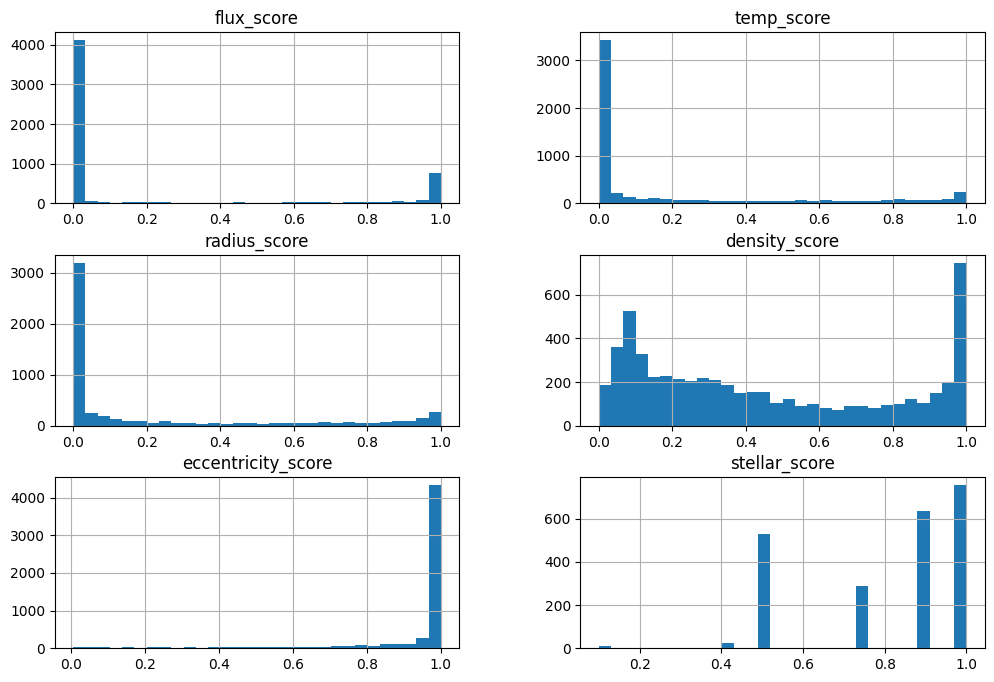

In [47]:
score_cols = ['flux_score', 'temp_score', 'radius_score', 'density_score', 'eccentricity_score', 'stellar_score']
df[score_cols].hist(figsize=(12, 8), bins=30)

In [48]:
print(df['pl_insol'].describe(percentiles=[.1,.25,.5,.75,.9]))
print(df['pl_eqt'].describe(percentiles=[.1,.25,.5,.75,.9]))

count      5715.000000
mean        532.630295
std        9979.045971
min           0.000000
10%           0.954840
25%          10.149000
50%          65.707000
75%         279.042500
90%         902.703400
max      636352.125800
Name: pl_insol, dtype: float64
count    5719.000000
mean      834.561960
std       494.651163
min         1.480000
10%       287.864000
25%       486.000000
50%       755.700000
75%      1093.000000
90%      1512.000000
max      7777.780000
Name: pl_eqt, dtype: float64


array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>]], dtype=object)

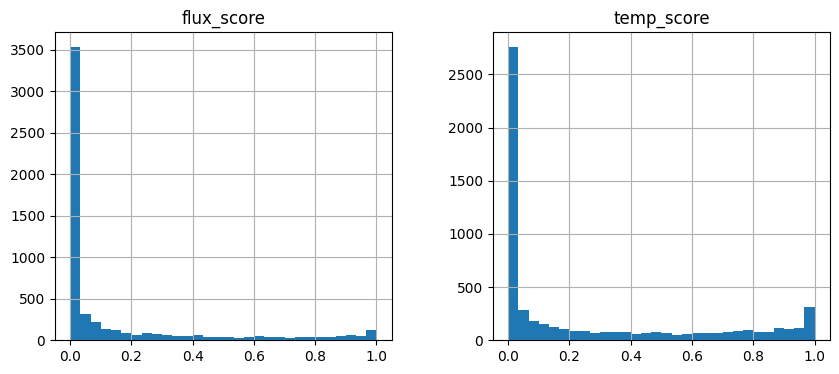

In [49]:
def score_gaussian_log(value, ideal_log, tolerance_log):
    if pd.isna(value) or value <= 0:
        return np.nan
    log_val = np.log10(value)
    return np.exp(-((log_val - ideal_log) ** 2) / (2 * tolerance_log ** 2))

def score_gaussian(value, ideal, tolerance):
    if pd.isna(value):
        return np.nan
    return np.exp(-((value - ideal) ** 2) / (2 * tolerance ** 2))

# Flux — log-space, ideal=log10(1.0)=0, tolerance_log=0.6 (covers ~1.5 orders of magnitude as "decent")
df['flux_score'] = df['pl_insol'].apply(lambda x: score_gaussian_log(x, ideal_log=0, tolerance_log=0.6))

# Temperature — linear, but widened to match real spread (75th percentile ~1093K, so tolerance needs to be in that ballpark)
df['temp_score'] = df['pl_eqt'].apply(lambda x: score_gaussian(x, ideal=255, tolerance=200))

df[['flux_score', 'temp_score']].hist(figsize=(10,4), bins=30)

array([[<Axes: title={'center': 'flux_score'}>,
        <Axes: title={'center': 'temp_score'}>],
       [<Axes: title={'center': 'radius_score'}>,
        <Axes: title={'center': 'density_score'}>],
       [<Axes: title={'center': 'eccentricity_score'}>,
        <Axes: title={'center': 'stellar_score'}>]], dtype=object)

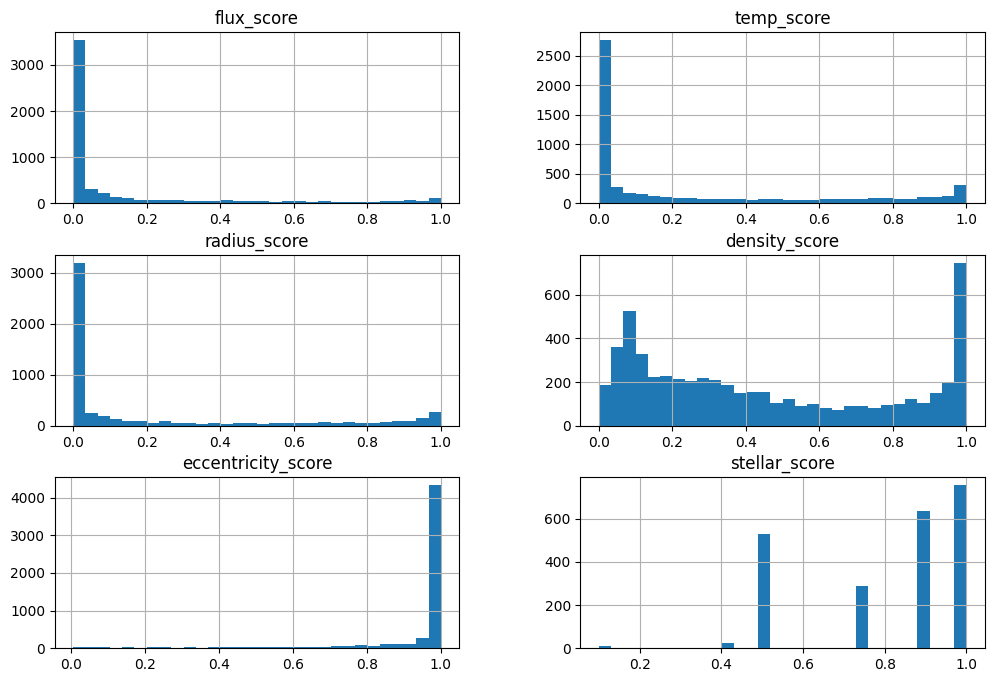

In [50]:
def score_asymmetric(value, ideal, tol_low, tol_high):
    if pd.isna(value):
        return np.nan
    tol = tol_low if value < ideal else tol_high
    return np.exp(-((value - ideal) ** 2) / (2 * tol ** 2))

df['radius_score'] = df['pl_rade'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.5, tol_high=0.6))
df['density_score'] = df['density_proxy'].apply(lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.4, tol_high=0.8))

def score_eccentricity(e, tolerance=0.3):
    if pd.isna(e):
        return np.nan
    return np.exp(-(e ** 2) / (2 * tolerance ** 2))

df['eccentricity_score'] = df['pl_orbeccen_filled'].apply(lambda x: score_eccentricity(x, tolerance=0.3))

stability_map = {'M': 0.5, 'K': 0.9, 'G': 1.0, 'F': 0.75, 'A': 0.4, 'B': 0.1, 'O': 0.05}
df['stellar_score'] = df['spectral_class'].map(stability_map)

score_cols = ['flux_score', 'temp_score', 'radius_score', 'density_score', 'eccentricity_score', 'stellar_score']
df[score_cols].hist(figsize=(12, 8), bins=30)

In [51]:
print(df['pl_orbeccen'].isna().sum(), "filled with 0 out of", len(df))

533 filled with 0 out of 5757


#Session 5

In [52]:
weights = {
    'flux_score': 0.25,
    'temp_score': 0.20,
    'radius_score': 0.20,
    'stellar_score': 0.15,
    'density_score': 0.10,
    'eccentricity_score': 0.10
}

assert sum(weights.values()) == 1.0, "Weights must sum to 1.0"

In [53]:
def compute_ehs(row, weights):
    available = {k: v for k, v in weights.items() if not pd.isna(row[k])}
    if not available:
        return np.nan
    total_weight = sum(available.values())
    return sum(row[k] * (w / total_weight) for k, w in available.items())

df['EHS'] = df.apply(lambda row: compute_ehs(row, weights), axis=1)

count    5757.000000
mean        0.349822
std         0.168945
min         0.013619
25%         0.218291
50%         0.323038
75%         0.458591
max         0.995124
Name: EHS, dtype: float64


<Axes: >

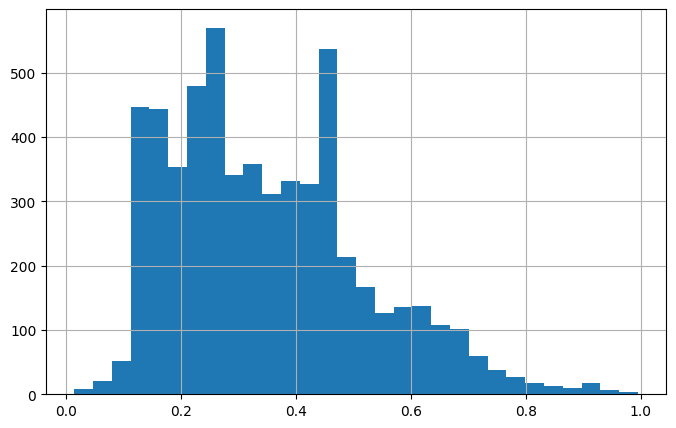

In [54]:
print(df['EHS'].describe())
df['EHS'].hist(bins=30, figsize=(8,5))

In [55]:
print(df.nlargest(10, 'EHS')[['pl_name', 'EHS']])
print(df.nsmallest(10, 'EHS')[['pl_name', 'EHS']])

                 pl_name       EHS
181          HD 160691 b  0.995124
1206       Kepler-1649 c  0.991220
5072        Kepler-438 b  0.982837
5551             K2-72 e  0.960911
2324       Kepler-1512 b  0.959805
545         Kepler-442 b  0.950341
3404       Kepler-1649 b  0.947351
5041          HD 10180 g  0.945357
4290         HD 160691 e  0.932589
3386  Teegarden's Star b  0.922214
           pl_name       EHS
5738  BD+42 2315 b  0.013619
2356     HATS-46 b  0.028115
3613   HD 144899 b  0.029974
1350    HD 56414 b  0.030335
1413     HATS-50 b  0.034289
3159     HATS-69 b  0.038946
2234     HATS-10 b  0.040253
52       HATS-32 b  0.044020
5431   HD 151450 b  0.049225
901    HD 105618 b  0.050466


In [56]:
print(df['spectral_class'].value_counts(dropna=False))

spectral_class
NaN    3504
G       755
K       638
M       531
F       288
A        23
B        10
W         2
D         2
L         1
S         1
Y         1
T         1
Name: count, dtype: int64


**Validation note:** Without hardcoding any known answers, the top-scoring EHS 
planets included Kepler-438 b, Kepler-442 b, and Kepler-1649 c — all independently 
recognized in the exoplanet science literature as among the most Earth-like candidates 
known. This convergence with expert consensus, achieved through transparent weighted 
scoring rather than a black-box model, is the core validation of the EHS approach.

#Session 6

In [57]:
reference_planets = pd.DataFrame([
    {
        'pl_name': 'Earth',
        'pl_rade': 1.0,           # Earth radii, by definition
        'pl_bmasse': 1.0,         # Earth masses, by definition
        'pl_insol': 1.0,          # Earth-relative insolation, by definition
        'pl_eqt': 255,            # equilibrium temp without greenhouse, Kelvin
        'pl_orbeccen': 0.017,
        'spectral_class': 'G',    # Sun is G2V
    },
    {
        'pl_name': 'Mars',
        'pl_rade': 0.532,
        'pl_bmasse': 0.107,
        'pl_insol': 0.431,
        'pl_eqt': 210,
        'pl_orbeccen': 0.094,
        'spectral_class': 'G',
    },
    {
        'pl_name': 'Venus',
        'pl_rade': 0.949,
        'pl_bmasse': 0.815,
        'pl_insol': 1.91,
        'pl_eqt': 232,            # equilibrium temp WITHOUT greenhouse (actual surface is ~737K, but eq. temp is the comparable metric)
        'pl_orbeccen': 0.007,
        'spectral_class': 'G',
    },
    {
        'pl_name': '51 Pegasi b (hot Jupiter)',
        'pl_rade': 14.0,          # roughly Jupiter-sized
        'pl_bmasse': 146.0,       # roughly half Jupiter's mass, Earth-mass units
        'pl_insol': 1700,         # extremely irradiated, ~4.2 day orbit
        'pl_eqt': 1260,
        'pl_orbeccen': 0.0,
        'spectral_class': 'G',
    },
])

reference_planets['density_proxy'] = reference_planets['pl_bmasse'] / (reference_planets['pl_rade'] ** 3)
reference_planets['pl_orbeccen_filled'] = reference_planets['pl_orbeccen'].fillna(0)

In [58]:
reference_planets['flux_score'] = reference_planets['pl_insol'].apply(
    lambda x: score_gaussian_log(x, ideal_log=0, tolerance_log=0.6))
reference_planets['temp_score'] = reference_planets['pl_eqt'].apply(
    lambda x: score_gaussian(x, ideal=255, tolerance=200))
reference_planets['radius_score'] = reference_planets['pl_rade'].apply(
    lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.5, tol_high=0.6))
reference_planets['density_score'] = reference_planets['density_proxy'].apply(
    lambda x: score_asymmetric(x, ideal=1.0, tol_low=0.4, tol_high=0.8))
reference_planets['eccentricity_score'] = reference_planets['pl_orbeccen_filled'].apply(
    lambda x: score_eccentricity(x, tolerance=0.3))

stability_map = {'M': 0.5, 'K': 0.9, 'G': 1.0, 'F': 0.75, 'A': 0.4, 'B': 0.1, 'O': 0.05}
reference_planets['stellar_score'] = reference_planets['spectral_class'].map(stability_map)

reference_planets['EHS'] = reference_planets.apply(lambda row: compute_ehs(row, weights), axis=1)

print(reference_planets[['pl_name', 'EHS']])

                     pl_name       EHS
0                      Earth  0.999840
1                       Mars  0.853906
2                      Venus  0.970973
3  51 Pegasi b (hot Jupiter)  0.256074


In [59]:
print(reference_planets[['pl_name', 'flux_score', 'temp_score', 'radius_score', 
                          'density_score', 'eccentricity_score', 'stellar_score', 'EHS']])

                     pl_name    flux_score  temp_score   radius_score  \
0                      Earth  1.000000e+00    1.000000   1.000000e+00   
1                       Mars  8.306348e-01    0.975005   6.452948e-01   
2                      Venus  8.961082e-01    0.993409   9.948115e-01   
3  51 Pegasi b (hot Jupiter)  5.072981e-07    0.000003  1.151951e-102   

   density_score  eccentricity_score  stellar_score       EHS  
0       1.000000            0.998396            1.0  0.999840  
1       0.769776            0.952096            1.0  0.853906  
2       0.993290            0.999728            1.0  0.970973  
3       0.060731            1.000000            1.0  0.256074  


## Validation finding: weighted-sum compression

Reference case testing revealed that 51 Pegasi b (a hot Jupiter) correctly scores 
near-zero on flux, temperature, and radius (radius_score = 1.15e-102) — but eccentricity 
and stellar stability both default to 1.0 for circular, Sun-like-star scenarios, 
contributing a flat 25% of weight regardless of the planet's actual habitability. 
This compresses the final EHS to 0.26 rather than near-zero.

This is an inherent property of additive weighted scoring: a factor that scores ~1.0 
uniformly across very different planets acts as a constant floor, diluting the signal 
from genuinely discriminating factors. EHS is therefore best interpreted as a relative 
ranking tool rather than an absolute probability — Earth (0.9998) meaningfully 
outranks 51 Pegasi b (0.256), and that relative ordering is reliable, even though 0.256 
should not be read as "26% likely habitable."

In [61]:
def compute_ehs(row, weights, hard_cutoff_factor='radius_score', hard_cutoff_threshold=0.01, hard_cutoff_cap=0.1):
    available = {k: v for k, v in weights.items() if not pd.isna(row[k])}
    if not available:
        return np.nan
    total_weight = sum(available.values())
    score = sum(row[k] * (w / total_weight) for k, w in available.items())
    
    if hard_cutoff_factor in row and row[hard_cutoff_factor] < hard_cutoff_threshold:
        return min(score, hard_cutoff_cap)
    return score

In [62]:

df['EHS'] = df.apply(lambda row: compute_ehs(row, weights), axis=1)

reference_planets['EHS'] = reference_planets.apply(lambda row: compute_ehs(row, weights), axis=1)

print(reference_planets[['pl_name', 'EHS']])

                     pl_name       EHS
0                      Earth  0.999840
1                       Mars  0.853906
2                      Venus  0.970973
3  51 Pegasi b (hot Jupiter)  0.100000


## Session 6: Validation results (final)

| Planet | EHS | Interpretation |
|---|---|---|
| Earth | 0.9998 | Correctly anchors at the top |
| Venus | 0.9710 | Higher than ideal — see limitation note below |
| Mars | 0.8539 | Higher than ideal — see limitation note below |
| 51 Pegasi b (hot Jupiter) | 0.1000 | Correctly near-zero after hard-cutoff fix |

**Known limitation:** Mars and Venus score higher than a strict reading of their 
habitability would suggest, because eccentricity and stellar-stability scores default 
to ~1.0 for circular orbits around Sun-like stars, propping up the weighted average. 
A hard physical disqualifier was added for radius (planets far too large/small to be 
rocky are capped low regardless of other factors), which correctly fixed the hot-Jupiter 
case. EHS is best read as a *relative ranking* tool — the ordering (Earth > Venus > 
Mars > hot Jupiter) is reliable — rather than as a calibrated absolute probability.

#Session 7

## Known limitation: no atmospheric factor

Venus (EHS 0.971) illustrates a genuine boundary of this model: its radius, density, 
eccentricity, and stellar environment are all close to Earth's, and even its flux 
(1.91x Earth) is only moderately off-ideal. EHS correctly reflects this physical 
similarity. Venus's actual uninhabitability comes from a runaway greenhouse 
atmosphere — a factor not included in this version of the model, since atmospheric 
composition data is sparse-to-absent for the vast majority of confirmed exoplanets 
in the archive. Adding an atmosphere-aware factor (or proxy) is listed under Future 
Improvements.